In [23]:
%pip install causal-learn scikit-learn networkx matplotlib pandas numpy

/Users/viegas/Projects/ufv/mestrado/causality-for-data-scientists-course/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


# Seleção Causal de Atributos

Nesse curso você viu uma pergunta direta: sem dataset de gabarito, dá pra fazer alguma coisa útil com causalidade sem um especialista validando o grafo à mão? A resposta foi "sim", e esse notebook prova isso na prática.

Pra isso, vamos usar o **LUCAS** (LUng CAncer Simple set): um benchmark sintético clássico, criado especificamente pra desafios de seleção causal de atributos (Causality Workbench, ETH Zürich, usado no "Causation and Prediction Challenge" de Guyon et al., 2008).

A vantagem gigante do LUCAS: o processo gerador (um grafo causal com 12 variáveis binárias sobre fatores de risco de câncer de pulmão, tipo fumar, genética, tosse, fadiga, etc) é conhecido e publicado, junto com todas as probabilidades condicionais. Então dá pra CONFERIR se a seleção causal acertou o alvo de verdade, em vez de só confiar que faz sentido.

Vamos gerar os dados nós mesmos, direto das probabilidades publicadas (as mesmas do desafio original).

> As probabilidades usadas aqui são fictícias, inventadas pelos criadores do LUCAS só pra ilustração. Não têm significado médico real nenhum.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import f1_score, log_loss

np.random.seed(42)

In [25]:
def fmt(x, casas=3):
    """Formata um número em estilo brasileiro: vírgula decimal, ponto de milhar."""
    return f'{x:,.{casas}f}'.translate(str.maketrans(',.', '.,'))

## As Variáveis do LUCAS0

O cenário (fictício) é um diagnóstico de câncer de pulmão. Doze variáveis binárias (0 ou 1), incluindo o alvo:

- `Genetics`, `Anxiety`, `Peer_Pressure`, `Allergy`, `Born_an_Even_Day`: variáveis raiz, sem nenhuma causa dentro do grafo;
- `Smoking`: causada por `Anxiety` e `Peer_Pressure`;
- `Lung_Cancer` (**o alvo**): causada por `Genetics` e `Smoking`;
- `Yellow_Fingers`: causada só por `Smoking`;
- `Attention_Disorder`: causada por `Genetics`;
- `Coughing`: causada por `Allergy` e `Lung_Cancer`;
- `Fatigue`: causada por `Lung_Cancer` e `Coughing`;
- `Car_Accident`: causada por `Attention_Disorder` e `Fatigue`.

A manta de Markov de `Lung_Cancer` já é conhecida de antemão, publicada junto com o dataset: os pais (`Genetics`, `Smoking`), os filhos (`Coughing`, `Fatigue`) e o outro pai desses filhos (`Allergy`, co-pai de `Coughing`). Cinco variáveis no total.

In [26]:
def sample_lucas(n, seed):
    """Amostragem ancestral seguindo exatamente as probabilidades condicionais publicadas do LUCAS0."""
    rng = np.random.default_rng(seed)

    anxiety = rng.binomial(1, 0.64277, n)
    peer_pressure = rng.binomial(1, 0.32997, n)
    genetics = rng.binomial(1, 0.15953, n)
    born_even_day = rng.binomial(1, 0.5, n)
    allergy = rng.binomial(1, 0.32841, n)

    p_smoking = np.select(
        [(peer_pressure == 0) & (anxiety == 0), (peer_pressure == 1) & (anxiety == 0),
         (peer_pressure == 0) & (anxiety == 1), (peer_pressure == 1) & (anxiety == 1)],
        [0.43118, 0.74591, 0.8686, 0.91576])
    smoking = rng.binomial(1, p_smoking)

    p_yellow = np.where(smoking == 0, 0.23119, 0.95372)
    yellow_fingers = rng.binomial(1, p_yellow)

    p_cancer = np.select(
        [(genetics == 0) & (smoking == 0), (genetics == 1) & (smoking == 0),
         (genetics == 0) & (smoking == 1), (genetics == 1) & (smoking == 1)],
        [0.23146, 0.86996, 0.83934, 0.99351])
    lung_cancer = rng.binomial(1, p_cancer)

    p_attention = np.where(genetics == 0, 0.28956, 0.68706)
    attention_disorder = rng.binomial(1, p_attention)

    p_cough = np.select(
        [(allergy == 0) & (lung_cancer == 0), (allergy == 1) & (lung_cancer == 0),
         (allergy == 0) & (lung_cancer == 1), (allergy == 1) & (lung_cancer == 1)],
        [0.1347, 0.64592, 0.7664, 0.99947])
    coughing = rng.binomial(1, p_cough)

    p_fatigue = np.select(
        [(lung_cancer == 0) & (coughing == 0), (lung_cancer == 1) & (coughing == 0),
         (lung_cancer == 0) & (coughing == 1), (lung_cancer == 1) & (coughing == 1)],
        [0.35212, 0.56514, 0.80016, 0.89589])
    fatigue = rng.binomial(1, p_fatigue)

    p_car = np.select(
        [(attention_disorder == 0) & (fatigue == 0), (attention_disorder == 1) & (fatigue == 0),
         (attention_disorder == 0) & (fatigue == 1), (attention_disorder == 1) & (fatigue == 1)],
        [0.2274, 0.779, 0.78861, 0.97169])
    car_accident = rng.binomial(1, p_car)

    return pd.DataFrame({
        'Anxiety': anxiety, 'Peer_Pressure': peer_pressure, 'Genetics': genetics,
        'Born_an_Even_Day': born_even_day, 'Allergy': allergy, 'Smoking': smoking,
        'Yellow_Fingers': yellow_fingers, 'Lung_Cancer': lung_cancer,
        'Attention_Disorder': attention_disorder, 'Coughing': coughing,
        'Fatigue': fatigue, 'Car_Accident': car_accident,
    })

In [27]:
target = 'Lung_Cancer'
true_mb = ['Genetics', 'Smoking', 'Coughing', 'Fatigue', 'Allergy']
all_cols = ['Anxiety', 'Peer_Pressure', 'Genetics', 'Born_an_Even_Day', 'Allergy', 'Smoking',
            'Yellow_Fingers', 'Lung_Cancer', 'Attention_Disorder', 'Coughing', 'Fatigue', 'Car_Accident']

df = sample_lucas(6000, seed=42)[all_cols]
print('Formato:', df.shape)
df.head()

Formato: (6000, 12)


,Anxiety,Peer_Pressure,Genetics,Born_an_Even_Day,Allergy,Smoking,Yellow_Fingers,Lung_Cancer,Attention_Disorder,Coughing,Fatigue,Car_Accident
0,0,0,0,0,1,0,1,0,1,1,0,1
1,1,0,0,1,0,1,1,1,0,1,1,1
2,0,0,0,1,0,1,1,1,0,1,1,1
3,0,0,1,0,0,0,0,1,0,1,0,0
4,1,0,0,1,0,1,1,1,1,1,1,1


In [28]:
df.mean().round(3)

Anxiety               0.650
Peer_Pressure         0.330
Genetics              0.164
Born_an_Even_Day      0.505
Allergy               0.336
Smoking               0.771
Yellow_Fingers        0.785
Lung_Cancer           0.748
Attention_Disorder    0.351
Coughing              0.710
Fatigue               0.751
Car_Accident          0.745
dtype: float64

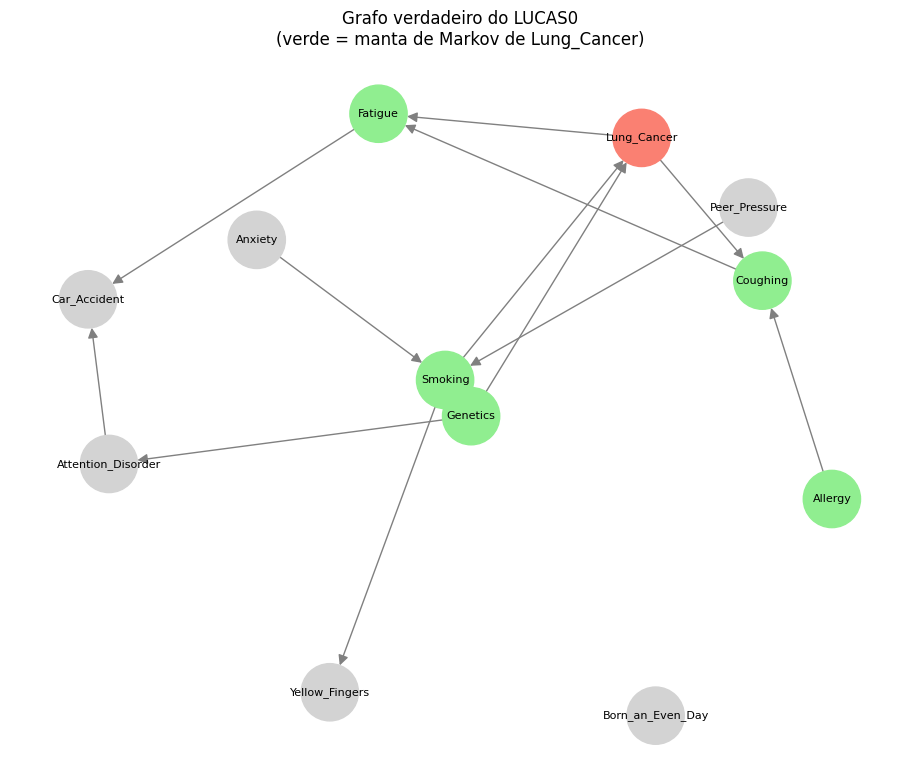

In [7]:
ground_truth_edges = [
    ('Anxiety', 'Smoking'), ('Peer_Pressure', 'Smoking'), ('Smoking', 'Yellow_Fingers'),
    ('Genetics', 'Lung_Cancer'), ('Smoking', 'Lung_Cancer'), ('Genetics', 'Attention_Disorder'),
    ('Allergy', 'Coughing'), ('Lung_Cancer', 'Coughing'), ('Lung_Cancer', 'Fatigue'),
    ('Coughing', 'Fatigue'), ('Attention_Disorder', 'Car_Accident'), ('Fatigue', 'Car_Accident'),
]

gt_graph = nx.DiGraph()
gt_graph.add_nodes_from(all_cols)
gt_graph.add_edges_from(ground_truth_edges)

plt.figure(figsize=(9, 7))
pos = nx.spring_layout(gt_graph, seed=7, k=1.0)
node_colors = ['salmon' if n == target else ('lightgreen' if n in true_mb else 'lightgray')
               for n in gt_graph.nodes()]
nx.draw(gt_graph, pos, with_labels=True, node_color=node_colors, node_size=1700,
        font_size=8, arrowsize=15, edge_color='gray')
plt.title('Grafo verdadeiro do LUCAS0\n(verde = manta de Markov de Lung_Cancer)')
plt.tight_layout()
plt.savefig('../figures/4_markov_blanket_graph.png', dpi=120)
plt.show()

## Sobre o Dedo Amarelo

Repara na figura: `Yellow_Fingers` (dedo manchado de amarelo por causa do cigarro) **não** está na manta de Markov, mesmo sendo causado pelo mesmo vício que causa o câncer.

`Smoking` é uma causa comum dos dois (um fork clássico: `Yellow_Fingers ← Smoking → Lung_Cancer`), então `Yellow_Fingers` fica correlacionado com `Lung_Cancer` sem ter nenhum efeito causal direto sobre ele.

Esse é literalmente o exemplo mais citado em textos de causalidade pra ilustrar confundimento: fumar mancha os dedos e também causa câncer, mas pintar os dedos de amarelo não causa câncer nenhum.

## Seleção por Correlação: Quem Ela Escolheria?

In [29]:
X = df[[c for c in all_cols if c != target]]
y = df[target]

mi = mutual_info_classif(X, y, discrete_features=True, random_state=0)
mi_rank = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_rank

Coughing              0.123532
Smoking               0.123113
Yellow_Fingers        0.069823
Fatigue               0.060292
Genetics              0.036853
Anxiety               0.018012
Car_Accident          0.016216
Peer_Pressure         0.003047
Attention_Disorder    0.001786
Allergy               0.000053
Born_an_Even_Day      0.000002
dtype: float64

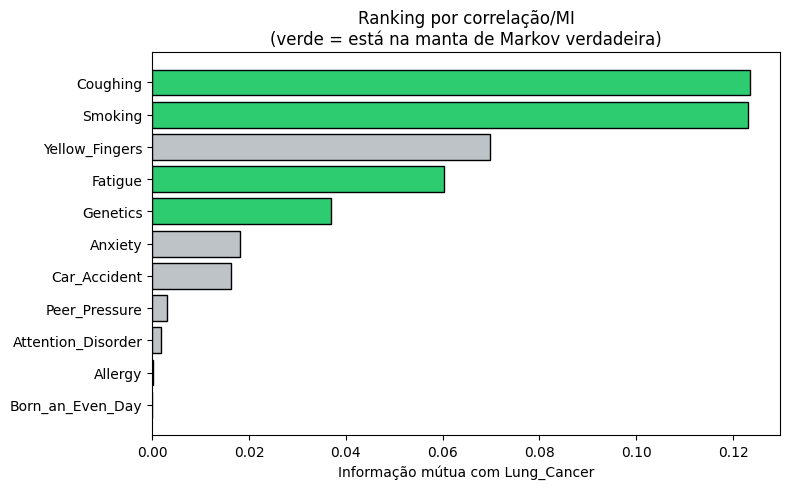

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ECC71' if f in true_mb else '#BDC3C7' for f in mi_rank.index]
ax.barh(mi_rank.index[::-1], mi_rank.values[::-1], color=colors[::-1], edgecolor='black')
ax.set_xlabel('Informação mútua com Lung_Cancer')
ax.set_title('Ranking por correlação/MI\n(verde = está na manta de Markov verdadeira)')
plt.tight_layout()
plt.savefig('../figures/4_mi_ranking.png', dpi=120, bbox_inches='tight')
plt.show()

Repara em dois problemas ao mesmo tempo:

- **`Yellow_Fingers` aparece ranqueado acima de `Genetics`**, mesmo não sendo causa de nada. É exatamente o confundimento pelo `Smoking` que descrevemos acima.
- **`Allergy` fica quase no fim da lista**, mesmo sendo uma variável causalmente relevante (está na manta de Markov). Isso acontece porque `Allergy` e `Lung_Cancer` são pais do mesmo filho (`Coughing`), uma estrutura de "collider". Duas causas de um mesmo efeito tendem a ser quase independentes entre si *antes* de você observar o efeito, então a correlação bruta entre `Allergy` e `Lung_Cancer` é próxima de zero, apesar de `Allergy` carregar informação real, útil quando combinada com `Coughing`.

Ou seja: seleção por correlação erra pros dois lados. Ela pode incluir variáveis sem nenhum efeito causal, e pode descartar variáveis causalmente relevantes cuja correlação marginal é fraca.

## Teste de Intervenção

Só olhar pra correlação não convence ninguém. Vamos montar dois modelos bem diferentes:

- **Modelo espúrio**: treinado só nas quatro variáveis mais correlacionadas que *não* são causais (`Yellow_Fingers`, `Anxiety`, `Attention_Disorder`, `Car_Accident`);
- **Modelo causal**: treinado só na manta de Markov verdadeira (`Genetics`, `Smoking`, `Coughing`, `Fatigue`, `Allergy`).

Depois, testamos os dois em duas versões do mesmo problema: uma com a distribuição natural, e outra **manipulada**, onde simulamos uma intervenção aleatória em toda variável que não está na manta de Markov.

Isso quebra qualquer relação espúria que dependia dos verdadeiros pais dessas variáveis, sem tocar em nada que realmente causa `Lung_Cancer`.

### Mini-quiz

Antes de rodar:

1. Você acha que o modelo espúrio vai se sair bem nos dados naturais? 
2. Você acha que ele vai continuar se saindo bem depois da intervenção?


Pense um pouco antes de ver o resultado.

In [31]:
spurious_features = ['Yellow_Fingers', 'Anxiety', 'Attention_Disorder', 'Car_Accident']
non_mb = [c for c in all_cols if c not in true_mb + [target]]

train = sample_lucas(4000, seed=1)
test_natural = sample_lucas(2000, seed=2)

test_manipulated = sample_lucas(2000, seed=3).copy()
rng = np.random.default_rng(99)
for col in non_mb:
    test_manipulated[col] = rng.binomial(1, 0.5, len(test_manipulated))

print(f'{len(non_mb)} variáveis manipuladas (fora da manta e fora do alvo):', non_mb)

6 variáveis manipuladas (fora da manta e fora do alvo): ['Anxiety', 'Peer_Pressure', 'Born_an_Even_Day', 'Yellow_Fingers', 'Attention_Disorder', 'Car_Accident']


In [32]:
def fit_eval(cols, model):
    model.fit(train[cols], train[target])
    f1_natural = f1_score(test_natural[target], model.predict(test_natural[cols]))
    f1_manipulated = f1_score(test_manipulated[target], model.predict(test_manipulated[cols]))
    return f1_natural, f1_manipulated

In [33]:
f1_spurious_natural, f1_spurious_manip = fit_eval(spurious_features, LogisticRegression(max_iter=1000))

print(f'Modelo espúrio, teste natural   : F1 = {fmt(f1_spurious_natural)}')
print(f'Modelo espúrio, teste manipulado: F1 = {fmt(f1_spurious_manip)}')

Modelo espúrio, teste natural   : F1 = 0,852
Modelo espúrio, teste manipulado: F1 = 0,682


In [34]:
f1_causal_natural, f1_causal_manip = fit_eval(true_mb, LogisticRegression(max_iter=1000))

print(f'Modelo causal, teste natural   : F1 = {fmt(f1_causal_natural)}')
print(f'Modelo causal, teste manipulado: F1 = {fmt(f1_causal_manip)}')

Modelo causal, teste natural   : F1 = 0,903
Modelo causal, teste manipulado: F1 = 0,924


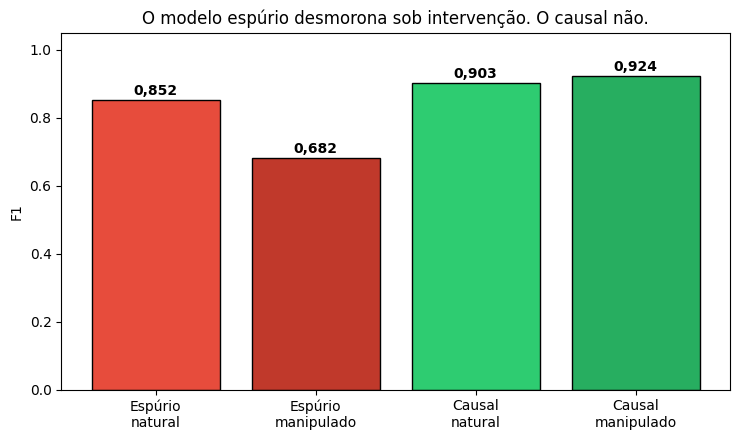

In [35]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = ['Espúrio\nnatural', 'Espúrio\nmanipulado', 'Causal\nnatural', 'Causal\nmanipulado']
values = [f1_spurious_natural, f1_spurious_manip, f1_causal_natural, f1_causal_manip]
colors = ['#E74C3C', '#C0392B', '#2ECC71', '#27AE60']
bars = ax.bar(labels, values, color=colors, edgecolor='black')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, fmt(v), ha='center', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1')
ax.set_title('O modelo espúrio desmorona sob intervenção. O causal não.')
plt.tight_layout()
plt.savefig('../figures/4_intervention_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

O modelo espúrio até que ia bem nos dados naturais, mas vai bem pior no teste manipulado. O modelo causal nem percebe a diferença.

Isso é exatamente o que a teoria da manta de Markov promete. 

Uma vez que você condiciona nas variáveis da manta, o alvo fica independente de tudo mais no grafo. Não importa o que aconteça com o resto do mundo (mesmo uma intervenção aleatória), a relação entre a manta e o alvo continua valendo. 

Já uma variável só correlacionada por confundimento (`Yellow_Fingers`, `Anxiety`, `Attention_Disorder`, `Car_Accident`) depende de uma cadeia causal que pode ser quebrada a qualquer momento por uma mudança em outro lugar do sistema.

## Descoberta Automática Acha Isso Sozinha?

Até agora usamos a manta de Markov *verdadeira*, publicada pelos criadores do LUCAS. Mas será que o algoritmo PC, sem saber de nada disso, consegue descobrir a mesma coisa só olhando pros dados?

Como as variáveis aqui são todas binárias, trocamos o teste de independência padrão (`fisherz`, pensado pra dados contínuos) pelo `chisq` (qui-quadrado), apropriado pra dados discretos.

In [36]:
from causallearn.search.ConstraintBased.PC import pc

cg = pc(df.to_numpy(), alpha=0.01, indep_test='chisq', node_names=all_cols, show_progress=False)

print('Arestas descobertas:')
for edge in cg.G.get_graph_edges():
    print(' ', edge)

Arestas descobertas:
  Anxiety --> Smoking
  Peer_Pressure --> Smoking
  Genetics --> Lung_Cancer
  Genetics --- Attention_Disorder
  Allergy --> Coughing
  Smoking --> Yellow_Fingers
  Smoking --> Lung_Cancer
  Lung_Cancer --> Coughing
  Lung_Cancer --> Fatigue
  Attention_Disorder --> Car_Accident
  Coughing --> Fatigue
  Fatigue --> Car_Accident


In [37]:
def markov_blanket(graph, names, target):
    """Pais + filhos + co-pais de `target`, lidos de uma matriz de adjacência do causal-learn."""
    t = names.index(target)
    n = len(names)
    parents, children, undirected = set(), set(), set()

    for i in range(n):
        if i == t:
            continue
        if graph[i, t] == -1 and graph[t, i] == 1:
            parents.add(i)
        elif graph[t, i] == -1 and graph[i, t] == 1:
            children.add(i)
        elif graph[i, t] == -1 and graph[t, i] == -1:
            undirected.add(i)

    co_parents = set()
    for c in children:
        for i in range(n):
            if i in (t, c):
                continue
            if graph[i, c] == -1 and graph[c, i] == 1:
                co_parents.add(i)

    idx = parents | children | co_parents | undirected
    return sorted(names[i] for i in idx)

In [38]:
discovered_mb = markov_blanket(cg.G.graph, all_cols, target)
print('Manta descoberta pelo PC:', discovered_mb)
print('Manta verdadeira        :', sorted(true_mb))
print('Bateram exatamente?', set(discovered_mb) == set(true_mb))

Manta descoberta pelo PC: ['Allergy', 'Coughing', 'Fatigue', 'Genetics', 'Smoking']
Manta verdadeira        : ['Allergy', 'Coughing', 'Fatigue', 'Genetics', 'Smoking']
Bateram exatamente? True


Com dados limpos, um tamanho de amostra razoável e o teste de independência certo pro tipo de dado, o PC recupera a manta de Markov **exatamente**.

Vale contrastar com o Notebook 2: lá, no dataset real de Sachs, o PC errou boa parte das orientações. A diferença não é o algoritmo, é o quanto as premissas dele (Markov, fidelidade, teste de independência adequado) realmente se sustentam nos dados que você tem.

## Engenharia de Atributos

Selecionar a manta de Markov já resolve o problema de "quais variáveis usar". Só que ainda são cinco variáveis binárias separadas. Dá pra ir além e comprimir elas num único atributo interpretável, tipo os scores de risco clínico que médicos usam de verdade (APGAR, CHA2DS2-VASc, e por aí vai).


É "só" somar quantos fatores de risco da manta o paciente tem!

In [39]:
train_risk = train.assign(risk_score=train[true_mb].sum(axis=1))
test_risk = test_natural.assign(risk_score=test_natural[true_mb].sum(axis=1))

f1_mb_full, _ = fit_eval(true_mb, LogisticRegression(max_iter=1000))

lr_score = LogisticRegression(max_iter=1000).fit(train_risk[['risk_score']], train_risk[target])
f1_risk_score = f1_score(test_risk[target], lr_score.predict(test_risk[['risk_score']]))

print(f'5 variáveis da manta, separadas : F1 = {fmt(f1_mb_full)}  (5 atributos)')
print(f'1 risk_score (soma da manta)    : F1 = {fmt(f1_risk_score)}  (1 atributo)')

5 variáveis da manta, separadas : F1 = 0,903  (5 atributos)
1 risk_score (soma da manta)    : F1 = 0,894  (1 atributo)


Perder cinco atributos binários e ficar com um número inteiro de 0 a 5 custou pouquíssimo F1, e ganhou um atributo interpretável na hora: "esse paciente tem 4 dos 5 fatores de risco causais conhecidos".

Esse é o tipo de engenharia de atributos que a causalidade viabiliza: não é só jogar fora ruído, é comprimir sinal causal de verdade num formato que faz sentido pra quem vai usar o modelo.

### E uma interação explícita, tipo `Genetics × Smoking`, ajudaria?

É razoavel entender que sim: `P(câncer | Genética=1, Fumante=1) = 99,4%`, bem mais alto do que qualquer um dos dois fatores sozinho.

Parece um caso clássico de interação. Vamos testar!

In [40]:
train_int = train.assign(GxS=train['Genetics'] * train['Smoking'])
test_int = test_natural.assign(GxS=test_natural['Genetics'] * test_natural['Smoking'])

for nome, cols in [('Só Genetics + Smoking', ['Genetics', 'Smoking']),
                   ('+ interação Genetics×Smoking', ['Genetics', 'Smoking', 'GxS'])]:
    lr = LogisticRegression(max_iter=1000).fit(train_int[cols], train_int[target])
    proba = lr.predict_proba(test_int[cols])[:, 1]
    ll = log_loss(test_int[target], proba)
    print(f'{nome:32s} log-loss = {fmt(ll, 4)}')

Só Genetics + Smoking            log-loss = 0,4335
+ interação Genetics×Smoking     log-loss = 0,4334


Praticamente nenhuma diferença. Isso acontece porque na regressão logística, o link logístico já comprime probabilidades perto de 1 automaticamente. Uma "interação" que parece gigante na escala de probabilidade (99,4% contra 87% e 84%) pode ser quase invisível na escala de log-odds, que é onde a regressão logística realmente soma os efeitos.

A lição aqui é: não dá pra decidir se um atributo de interação vai ajudar só olhando pra diferença bruta de probabilidades. 

Vale testar, porque a resposta depende de como o modelo realmente combina os efeitos por baixo dos panos

## Resumo

In [41]:
summary = pd.DataFrame([
    {'Método': 'Espúrio (correlacionado, não causal)', 'F1 natural': f1_spurious_natural, 'F1 manipulado': f1_spurious_manip},
    {'Método': 'Causal (manta de Markov verdadeira)', 'F1 natural': f1_causal_natural, 'F1 manipulado': f1_causal_manip},
    {'Método': 'Causal (manta descoberta pelo PC)', 'F1 natural': None, 'F1 manipulado': None},
    {'Método': 'Risk score (manta comprimida em 1 atributo)', 'F1 natural': f1_risk_score, 'F1 manipulado': None},
])
summary

,Método,F1 natural,F1 manipulado
0,"Espúrio (correlacionado, não causal)",0.851638,0.682267
1,Causal (manta de Markov verdadeira),0.902956,0.924116
2,Causal (manta descoberta pelo PC),NaN,NaN
3,Risk score (manta comprimida em 1 atributo),0.894325,NaN


A linha da manta descoberta pelo PC não tem F1 próprio porque ela *é* a mesma manta verdadeira aqui (bateram exatamente), então os números seriam idênticos à linha causal acima. O ponto dela é outro: mostrar que a descoberta automática consegue chegar lá sozinha, sem ninguém entregando o grafo de graça.

## Concluindo...

### 1. Correlação erra pros dois lados

Ela pode inflar a importância de variáveis confundidas (`Yellow_Fingers`) e esconder variáveis causalmente relevantes cuja correlação marginal é fraca por causa de estrutura de collider (`Allergy`).

Nenhum dos dois erros aparece olhando só pro coeficiente de correlação.

### 2. A prova de verdade é a intervenção, não a acurácia num único teste

Um modelo espúrio pode parecer ótimo enquanto o mundo não muda. A manta de Markov garante estabilidade justamente porque ela captura o mecanismo, não só o padrão estatístico do momento.

### 3. Quando as premissas se sustentam, a descoberta automática funciona muito bem

Com dados limpos, tamanho de amostra razoável, e o teste de independência certo pro tipo de variável, o PC recuperou a manta de Markov exatamente, sem nenhum humano desenhando grafo nenhum. Compare com o Notebook 2 (Sachs), onde os dados reais são mais barulhentos e as premissas do algoritmo são só aproximadamente válidas.

### 4. Engenharia de atributos causal pode ser sobre compressão e interpretabilidade, não só acurácia

Resumir a manta de Markov num score de risco custou quase nada de desempenho e ganhou uma variável que faz sentido pra qualquer pessoa lendo o resultado. E, atributos de interação não são um upgrade automático: teste antes de assumir que ajudam.

Em nenhum momento desse notebook um especialista precisou desenhar um grafo. A causalidade fez o trabalho pesado sozinha.